# Replay v6 — is there an optimum?

Fits a FOV-level ExactGP+MCMC on the v6 run data with
`frac_responders` as target (fraction of cells in a FOV whose
per-cell `mean_osc_probability >= 0.75`).  Rows with
`optortk_expression <= 0` are dropped (they poisoned the live GP
via `log_scale=True` → `log(0) = -inf`, which is why the live
BO couldn't fit).

Goal: look at the data from three angles and decide whether
`(stim_exposure, ramp)` actually moves the outcome in the tested range.

1. Raw scatter: target vs each BO parameter, per phase.
2. Phase-summary table + barplot of mean target per phase.
3. GP-predicted 2D landscape with uncertainty, peak location,
   and a holdout diagnostic to flag "flat surface + random noise"
   as the honest answer.

In [14]:
import os, glob, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# gpax/numpyro compat
import numpyro.contrib.module as _ncm


def _h(*_a, **_k):
    raise NotImplementedError("haiku removed")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _h
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _h

# ---- config ----
RUN_PATH = r"E:\Alex\2026-04-14_bo_erk_oscillation_v6_test"
EXP_DATA_PATH = os.path.join(RUN_PATH, "exp_data.parquet")

N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY
FIRST_FRAME_STIM = N_FRAMES_BASELINE
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM

CLASSIFIER_PATH = r"./oscillation_model_60min.joblib"
CLASSIFIER_SCRIPT = r"./apply_oscillation_classifier_v2.py"

RESPONDER_THRESHOLD = 0.75

In [15]:
import joblib

model_data = joblib.load(CLASSIFIER_PATH)
osc_clf = model_data["clf"]
osc_scaler = model_data["scaler"]
osc_feature_cols = model_data["feature_cols"]
osc_cfg = model_data["config"]
osc_cfg["window_size"] = model_data["window_size"]
osc_cfg["window_step"] = model_data["window_step"]

_spec = importlib.util.spec_from_file_location("osc_clf_mod", CLASSIFIER_SCRIPT)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
predict_trace = _mod.predict_trace

df_exp = pd.read_parquet(EXP_DATA_PATH)
cond_map_df = (
    df_exp.groupby(["phase_id", "fov"])
    .agg(
        phase_name=("phase_name", "first"),
        stim_exposure=("stim_exposure", "first"),
        ramp=("ramp", "first"),
    )
    .reset_index()
)
phases = sorted(df_exp["phase_id"].unique())
print(
    f"Loaded {len(df_exp)} rows, {len(phases)} phases, {df_exp['fov'].nunique()} FOVs"
)
print(cond_map_df.head(20))

Loaded 721651 rows, 9 phases, 162 FOVs
    phase_id  fov        phase_name  stim_exposure  ramp
0          0    0  BO_iter_0_cond_0           85.0  12.0
1          0    1  BO_iter_0_cond_0           85.0  12.0
2          0    2  BO_iter_0_cond_0           85.0  12.0
3          0    3  BO_iter_0_cond_0           85.0  12.0
4          0    4  BO_iter_0_cond_0           85.0  12.0
5          0    5  BO_iter_0_cond_0           85.0  12.0
6          0    6  BO_iter_0_cond_0           85.0  12.0
7          0    7  BO_iter_0_cond_0           85.0  12.0
8          0    8  BO_iter_0_cond_0           85.0  12.0
9          0    9  BO_iter_0_cond_1          725.0  34.0
10         0   10  BO_iter_0_cond_1          725.0  34.0
11         0   11  BO_iter_0_cond_1          725.0  34.0
12         0   12  BO_iter_0_cond_1          725.0  34.0
13         0   13  BO_iter_0_cond_1          725.0  34.0
14         0   14  BO_iter_0_cond_1          725.0  34.0
15         0   15  BO_iter_0_cond_1          725.

## Single-cell preprocessing (classifier + quality gates)

In [16]:
from faro.agents.bo_optimization import BO_Parameter, BO_Objective, BO_Covariate
from faro.agents.bo_oscillation import OscillationBO
from faro.agents.bo_oscillation_single_cell import OscillationBOSingleCell

bo_params = [
    BO_Parameter(name="stim_exposure", bounds=(0.0, 1000.0), spacing=25.0),
    BO_Parameter(name="ramp", bounds=(0.0, 50.0), spacing=5.0),
]

shared_kwargs = dict(
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=60,
    imaging_channels=(),
    stim_channel=None,
    optocheck_channel=None,
    osc_clf=osc_clf,
    osc_scaler=osc_scaler,
    osc_feature_cols=osc_feature_cols,
    osc_cfg=osc_cfg,
    osc_predict_fn=predict_trace,
    min_osc_probability=0.0,
    min_consecutive_windows=0,
    min_fft_amplitude=0.0,
    n_baseline_frames=N_FRAMES_BASELINE,
    parameters_to_optimize=bo_params,
    n_iterations=len(phases),
    n_conditions_per_iter=2,
    n_initial_phases=2,
    acquisition_function="ei",
    n_cov_samples=20,
    ei_xi=0.2,
    ei_xi_final=0.01,
    ei_xi_decay_fraction=0.7,
    plot_live=False,
    save_checkpoints=False,
    verbose=False,
)

# Single-cell preprocessor (gives us per-cell mean_osc_probability)
_pre_agent = OscillationBOSingleCell(
    storage_path=os.path.join(RUN_PATH, "replay_v6_pre"),
    gp_backend="vi_sparse",
    inducing_points_ratio=0.1,
    num_svi_steps=10,
    svi_step_size=5e-3,
    gp_batch_size=2000,
    density_k_neighbours=5,
    bo_covariates=[
        BO_Covariate(name="baseline_cnr"),
        BO_Covariate(name="optortk_expression", log_scale=True),
        BO_Covariate(name="mean_dist_k_nearest"),
    ],
    objective_metric=BO_Objective(name="mean_osc_probability", goal="maximize"),
    **shared_kwargs,
)
os.makedirs(_pre_agent.storage_path, exist_ok=True)
_pre_agent._ensure_results_df()

# FOV-level preprocessor (gives us n_cells, baseline_cnr, optortk_expression)
_fov_pre = OscillationBO(
    storage_path=os.path.join(RUN_PATH, "replay_v6_fov_pre"),
    bo_covariates=[
        BO_Covariate(name="baseline_cnr"),
        BO_Covariate(name="optortk_expression", log_scale=True),
        BO_Covariate(name="n_cells"),
    ],
    objective_metric=BO_Objective(name="frac_responders", goal="maximize"),
    frac_responder_threshold=RESPONDER_THRESHOLD,
    **shared_kwargs,
)
os.makedirs(_fov_pre.storage_path, exist_ok=True)
_fov_pre._ensure_results_df()

all_cell_rows, all_fov_rows = [], []
for phase_id in phases:
    df_phase_raw = df_exp[df_exp["phase_id"] == phase_id]
    fov_tracks = {
        int(fov): df_phase_raw[df_phase_raw["fov"] == fov].copy()
        for fov in df_phase_raw["fov"].unique()
    }
    cm = cond_map_df[cond_map_df["phase_id"] == phase_id]
    cond_map = {
        int(row["fov"]): dict(
            stim_exposure=float(row["stim_exposure"]), ramp=float(row["ramp"])
        )
        for _, row in cm.iterrows()
    }
    _pre_agent._current_condition_map = cond_map
    _pre_agent._current_phase_id = int(phase_id)
    df_cell = _pre_agent._preprocess_results(fov_tracks)
    if not df_cell.empty:
        all_cell_rows.append(df_cell)

    _fov_pre._current_condition_map = cond_map
    _fov_pre._current_phase_id = int(phase_id)
    df_fov = _fov_pre._preprocess_results(fov_tracks)
    if not df_fov.empty:
        all_fov_rows.append(df_fov)

df_cells = pd.concat(all_cell_rows, ignore_index=True)
df_fovs = pd.concat(all_fov_rows, ignore_index=True)

# Attach phase_name
name_map = cond_map_df[["phase_id", "fov", "phase_name"]]
df_cells = df_cells.merge(name_map, on=["phase_id", "fov"], how="left")
df_fovs = df_fovs.merge(name_map, on=["phase_id", "fov"], how="left")

# Drop log-scale-incompatible rows
n_c0, n_f0 = len(df_cells), len(df_fovs)
df_cells = df_cells[df_cells["optortk_expression"] > 0].reset_index(drop=True)
df_fovs = df_fovs[df_fovs["optortk_expression"] > 0].reset_index(drop=True)
print(
    f"Dropped {n_c0 - len(df_cells)} cells and {n_f0 - len(df_fovs)} FOVs with optortk_expression <= 0"
)
print(f"df_cells: {len(df_cells)}   df_fovs: {len(df_fovs)}")

  Phase 0: 85 cells (from 13 FOVs), mean mean_osc_probability=0.0426, max=0.6050
  Phase 0: 8 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 1: 423 cells (from 18 FOVs), mean mean_osc_probability=0.1423, max=0.9764
  Phase 1: 17 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 2: 596 cells (from 18 FOVs), mean mean_osc_probability=0.1802, max=0.9653
  Phase 2: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 3: 508 cells (from 18 FOVs), mean mean_osc_probability=0.1313, max=0.9980
  Phase 3: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 4: 695 cells (from 18 FOVs), mean mean_osc_probability=0.1340, max=0.9837
  Phase 4: 18 FOVs, mean frac_oscillating=0.9990, max=1.0000
  Phase 5: 675 cells (from 18 FOVs), mean mean_osc_probability=0.1591, max=0.9981
  Phase 5: 17 FOVs, mean frac_oscillating=1.0000, max=1.0000
  Phase 6: 601 cells (from 18 FOVs), mean mean_osc_probability=0.1346, max=0.9966
  Phase 6: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
 

## Compute `frac_responders` per FOV

In [17]:
# df_fovs already has frac_responders (computed by OscillationBO._preprocess_results
# using frac_responder_threshold=0.75 on per-cell mean_osc_probability).
# Re-derive here from df_cells for clarity / to allow changing the threshold
# without re-running the full FOV preprocessing.
frac = (
    df_cells.groupby(["phase_id", "fov"])
    .agg(
        frac_responders_calc=(
            "mean_osc_probability",
            lambda s: float((s >= RESPONDER_THRESHOLD).mean()),
        )
    )
    .reset_index()
)
df_fovs_r = df_fovs.merge(frac, on=["phase_id", "fov"], how="left")
# Prefer the replay-computed value (configurable via RESPONDER_THRESHOLD at the top)
df_fovs_r["frac_responders"] = df_fovs_r["frac_responders_calc"].fillna(0.0)
df_fovs_r = df_fovs_r.drop(columns=["frac_responders_calc"])

print(
    f"frac_responders range: {df_fovs_r["frac_responders"].min():.3f} - {df_fovs_r["frac_responders"].max():.3f}"
)
print(
    f"  mean={df_fovs_r["frac_responders"].mean():.3f}  std={df_fovs_r["frac_responders"].std():.3f}"
)
print(f"  {(df_fovs_r["frac_responders"]<0.01).sum()}/{len(df_fovs_r)} FOVs near 0")
print(f"  {(df_fovs_r["frac_responders"]>0.99).sum()}/{len(df_fovs_r)} FOVs near 1")

frac_responders range: 0.000 - 0.209
  mean=0.032  std=0.048
  65/115 FOVs near 0
  0/115 FOVs near 1


## Diagnostic 1 — raw scatter: target vs each BO parameter

If `(stim_exposure, ramp)` drives the outcome, we should see a trend by eye.
Coloured by phase, shape by ramp value for the stim_exposure plot and vice versa.

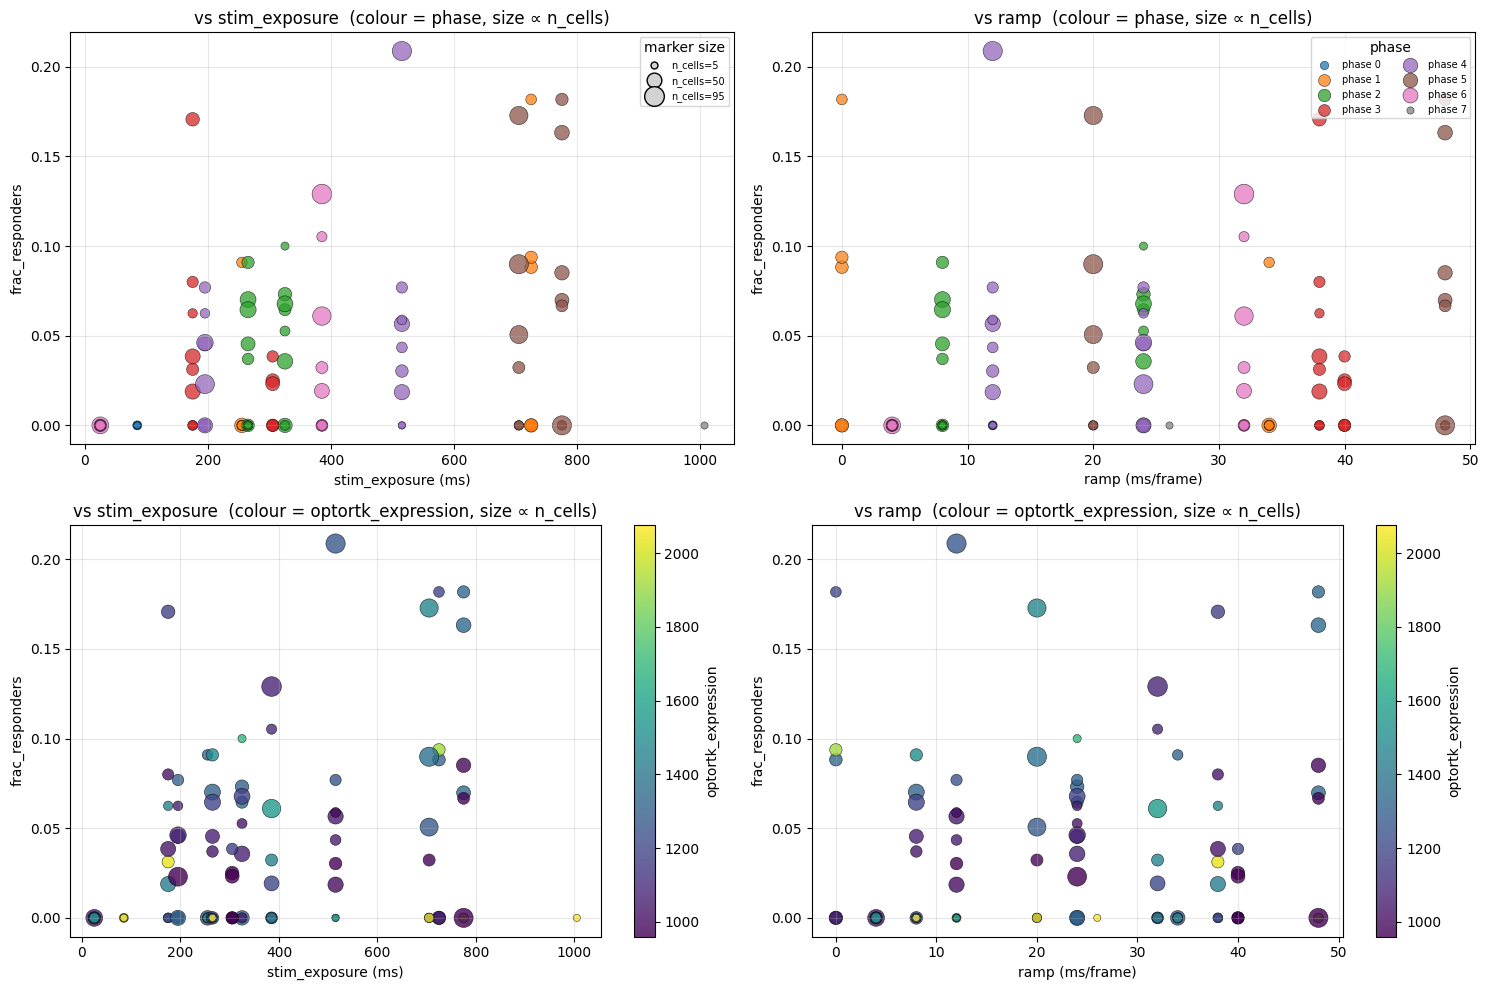

=== Spearman correlations with frac_responders ===
  stim_exposure           : rho = +0.182
  ramp                    : rho = +0.056
  n_cells                 : rho = +0.535
  optortk_expression      : rho = -0.298
  baseline_cnr            : rho = -0.539


In [18]:
# 2x2 grid: show frac_responders vs both BO parameters, in two encodings:
#   Row 1 (color=phase, size ∝ n_cells): see the BO trajectory and sample weight
#   Row 2 (color=optortk_expression, size ∝ n_cells): see the covariate effect
from matplotlib.lines import Line2D

phases_unique = sorted(df_fovs_r["phase_id"].unique())
ramps_unique = sorted(df_fovs_r["ramp"].unique())
cmap = plt.cm.tab10

# Size normalised from n_cells. Clamp to a visible range.
n_cells = df_fovs_r["n_cells"].to_numpy(dtype=float)
n_cells_min, n_cells_max = float(n_cells.min()), float(n_cells.max())


def size_from_n_cells(n):
    n = np.asarray(n, dtype=float)
    if n_cells_max <= n_cells_min:
        return np.full_like(n, 60.0)
    s = 25.0 + 175.0 * (n - n_cells_min) / (n_cells_max - n_cells_min)
    return s


fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Row 1: colour = phase, size = n_cells
for col, (xcol, xlabel) in enumerate(
    [
        ("stim_exposure", "stim_exposure (ms)"),
        ("ramp", "ramp (ms/frame)"),
    ]
):
    ax = axes[0, col]
    for pid in phases_unique:
        sub = df_fovs_r[df_fovs_r["phase_id"] == pid]
        if sub.empty:
            continue
        ax.scatter(
            sub[xcol],
            sub["frac_responders"],
            c=[cmap(pid % 10)],
            s=size_from_n_cells(sub["n_cells"].to_numpy(dtype=float)),
            alpha=0.75,
            edgecolors="black",
            linewidths=0.4,
            label=f"phase {pid}" if col == 1 else None,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("frac_responders")
    ax.set_title(f"vs {xcol}  (colour = phase, size ∝ n_cells)")
    ax.grid(alpha=0.3)
axes[0, 1].legend(fontsize=7, ncol=2, loc="upper right", title="phase")
# Size legend on row 1, col 0
n_ref = [n_cells_min, (n_cells_min + n_cells_max) / 2, n_cells_max]
size_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="lightgray",
        markeredgecolor="black",
        markersize=np.sqrt(size_from_n_cells(np.array([n]))[0]),
        label=f"n_cells={int(n)}",
    )
    for n in n_ref
]
axes[0, 0].legend(
    handles=size_handles, fontsize=7, loc="upper right", title="marker size"
)

# Row 2: colour = optortk_expression (continuous), size = n_cells
optortk = df_fovs_r["optortk_expression"].to_numpy(dtype=float)
vmin = float(np.quantile(optortk, 0.05))
vmax = float(np.quantile(optortk, 0.95))
for col, (xcol, xlabel) in enumerate(
    [
        ("stim_exposure", "stim_exposure (ms)"),
        ("ramp", "ramp (ms/frame)"),
    ]
):
    ax = axes[1, col]
    sc = ax.scatter(
        df_fovs_r[xcol],
        df_fovs_r["frac_responders"],
        c=optortk,
        cmap="viridis",
        s=size_from_n_cells(n_cells),
        alpha=0.80,
        edgecolors="black",
        linewidths=0.4,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("frac_responders")
    ax.set_title(f"vs {xcol}  (colour = optortk_expression, size ∝ n_cells)")
    ax.grid(alpha=0.3)
    fig.colorbar(sc, ax=ax, label="optortk_expression")

plt.tight_layout()
plt.show()

# Quick numeric sanity — correlations
print("=== Spearman correlations with frac_responders ===")
for col in ("stim_exposure", "ramp", "n_cells", "optortk_expression", "baseline_cnr"):
    if col not in df_fovs_r.columns:
        continue
    r = df_fovs_r[[col, "frac_responders"]].corr(method="spearman").iloc[0, 1]
    print(f"  {col:24s}: rho = {r:+.3f}")

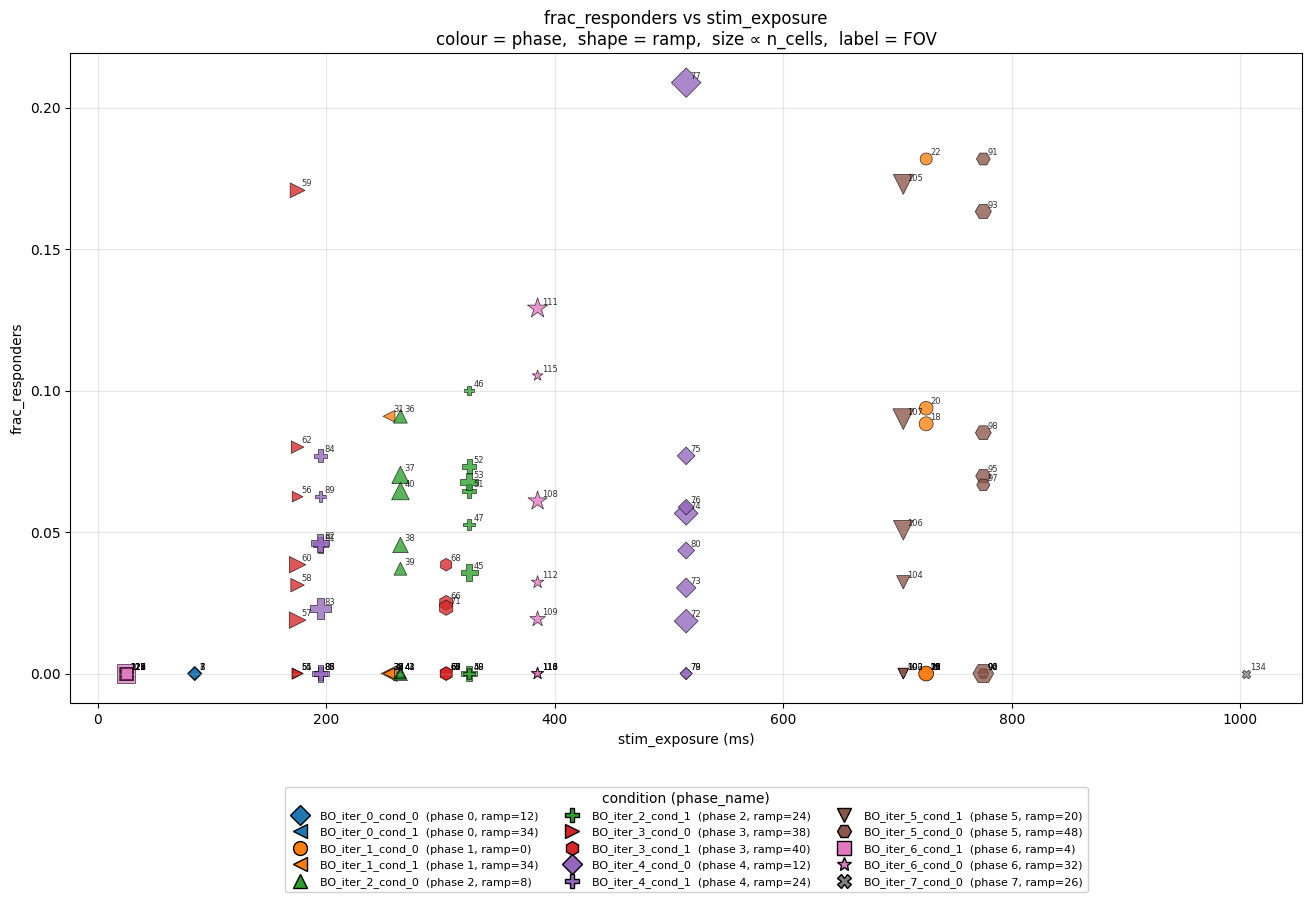

In [22]:
# frac_responders vs stim_exposure — legend below the plot
# plus a small FOV number annotated on each point
from matplotlib.lines import Line2D

pair_to_name = df_fovs_r.groupby(["phase_id", "ramp"])["phase_name"].first().to_dict()

phases_unique = sorted(df_fovs_r["phase_id"].unique())
ramps_unique = sorted(df_fovs_r["ramp"].unique())
cmap = plt.cm.tab10
marker_pool = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H", "p", "8"]
ramp_to_marker = {
    r: marker_pool[i % len(marker_pool)] for i, r in enumerate(ramps_unique)
}


def size_from_n_cells(n):
    n = np.asarray(n, dtype=float)
    n_min = float(df_fovs_r["n_cells"].min())
    n_max = float(df_fovs_r["n_cells"].max())
    if n_max <= n_min:
        return np.full_like(n, 80.0)
    return 35.0 + 200.0 * (n - n_min) / (n_max - n_min)


fig, ax = plt.subplots(figsize=(14, 10))

legend_handles = []
for pid in phases_unique:
    for r in ramps_unique:
        sub = df_fovs_r[(df_fovs_r["phase_id"] == pid) & (df_fovs_r["ramp"] == r)]
        if sub.empty:
            continue
        ax.scatter(
            sub["stim_exposure"],
            sub["frac_responders"],
            c=[cmap(pid % 10)],
            marker=ramp_to_marker[r],
            s=size_from_n_cells(sub["n_cells"].to_numpy(dtype=float)),
            alpha=0.78,
            edgecolors="black",
            linewidths=0.5,
        )
        # Annotate each point with its FOV number
        for _, row in sub.iterrows():
            ax.annotate(
                f"{int(row['fov'])}",
                xy=(row["stim_exposure"], row["frac_responders"]),
                xytext=(3, 3),  # small pixel offset
                textcoords="offset points",
                fontsize=6,
                color="black",
                alpha=0.8,
            )
        name = pair_to_name.get((pid, r), f"phase_{pid}_ramp_{r:g}")
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker=ramp_to_marker[r],
                color="w",
                markerfacecolor=cmap(pid % 10),
                markeredgecolor="black",
                markersize=10,
                label=f"{name}  (phase {pid}, ramp={r:g})",
            )
        )

ax.set_xlabel("stim_exposure (ms)")
ax.set_ylabel("frac_responders")
ax.set_title(
    "frac_responders vs stim_exposure\ncolour = phase,  shape = ramp,  size ∝ n_cells,  label = FOV"
)
ax.grid(alpha=0.3)

ax.legend(
    handles=legend_handles,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    title="condition (phase_name)",
    framealpha=0.9,
)

fig.subplots_adjust(left=0.08, right=0.96, top=0.93, bottom=0.28)
plt.show()

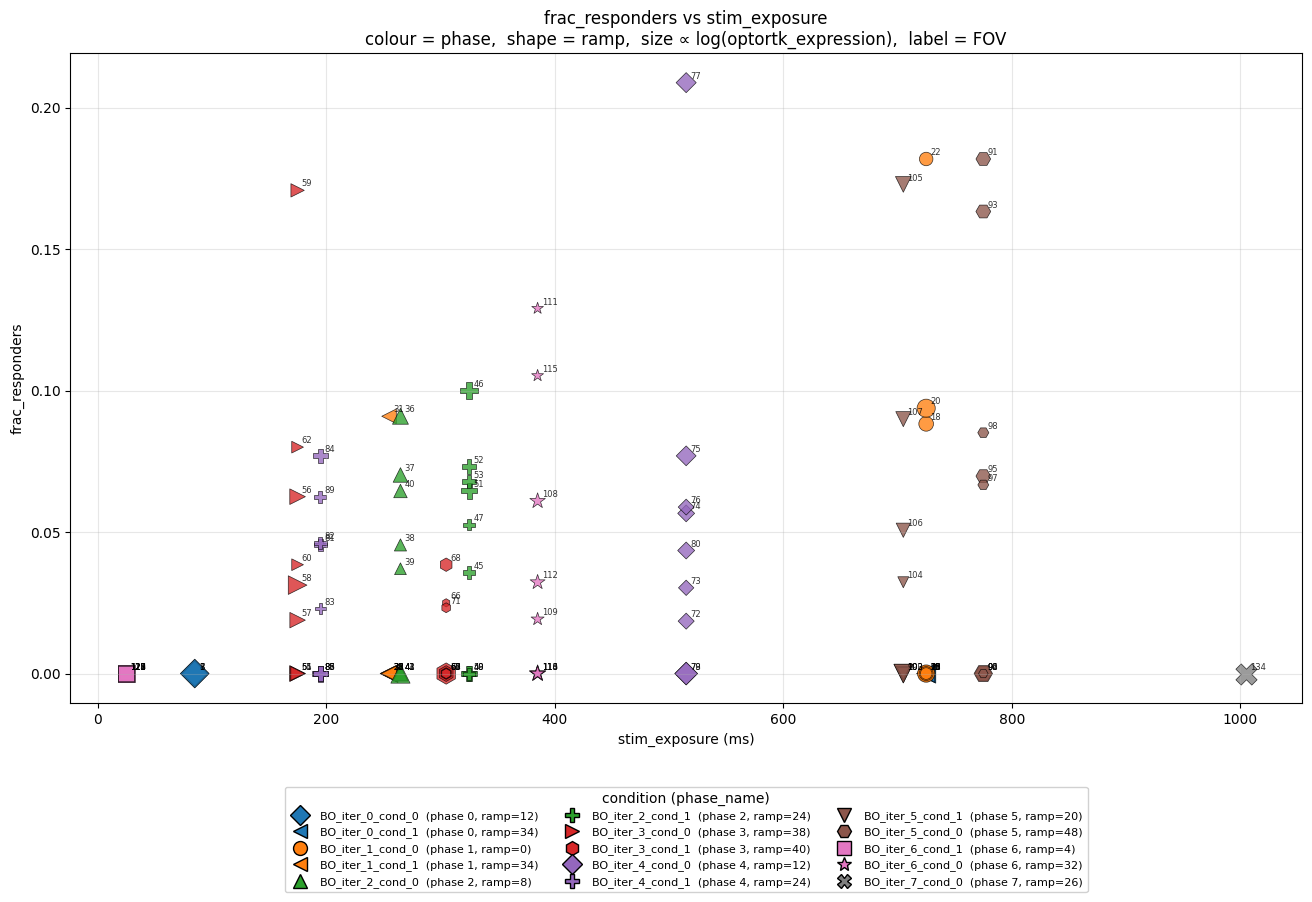

In [23]:
# frac_responders vs stim_exposure
# size ∝ optortk_expression (log-scaled so the range compresses)
from matplotlib.lines import Line2D

pair_to_name = df_fovs_r.groupby(["phase_id", "ramp"])["phase_name"].first().to_dict()

phases_unique = sorted(df_fovs_r["phase_id"].unique())
ramps_unique = sorted(df_fovs_r["ramp"].unique())
cmap = plt.cm.tab10
marker_pool = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H", "p", "8"]
ramp_to_marker = {
    r: marker_pool[i % len(marker_pool)] for i, r in enumerate(ramps_unique)
}

opto_log = np.log(df_fovs_r["optortk_expression"].to_numpy(dtype=float))
opto_min, opto_max = float(opto_log.min()), float(opto_log.max())


def size_from_opto(vals):
    v = np.log(np.asarray(vals, dtype=float))
    if opto_max <= opto_min:
        return np.full_like(v, 80.0)
    return 35.0 + 200.0 * (v - opto_min) / (opto_max - opto_min)


fig, ax = plt.subplots(figsize=(14, 10))

legend_handles = []
for pid in phases_unique:
    for r in ramps_unique:
        sub = df_fovs_r[(df_fovs_r["phase_id"] == pid) & (df_fovs_r["ramp"] == r)]
        if sub.empty:
            continue
        ax.scatter(
            sub["stim_exposure"],
            sub["frac_responders"],
            c=[cmap(pid % 10)],
            marker=ramp_to_marker[r],
            s=size_from_opto(sub["optortk_expression"].to_numpy(dtype=float)),
            alpha=0.78,
            edgecolors="black",
            linewidths=0.5,
        )
        for _, row in sub.iterrows():
            ax.annotate(
                f"{int(row['fov'])}",
                xy=(row["stim_exposure"], row["frac_responders"]),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=6,
                color="black",
                alpha=0.8,
            )
        name = pair_to_name.get((pid, r), f"phase_{pid}_ramp_{r:g}")
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker=ramp_to_marker[r],
                color="w",
                markerfacecolor=cmap(pid % 10),
                markeredgecolor="black",
                markersize=10,
                label=f"{name}  (phase {pid}, ramp={r:g})",
            )
        )

ax.set_xlabel("stim_exposure (ms)")
ax.set_ylabel("frac_responders")
ax.set_title(
    "frac_responders vs stim_exposure\ncolour = phase,  shape = ramp,  size ∝ log(optortk_expression),  label = FOV"
)
ax.grid(alpha=0.3)

ax.legend(
    handles=legend_handles,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    title="condition (phase_name)",
    framealpha=0.9,
)
fig.subplots_adjust(left=0.08, right=0.96, top=0.93, bottom=0.28)
plt.show()

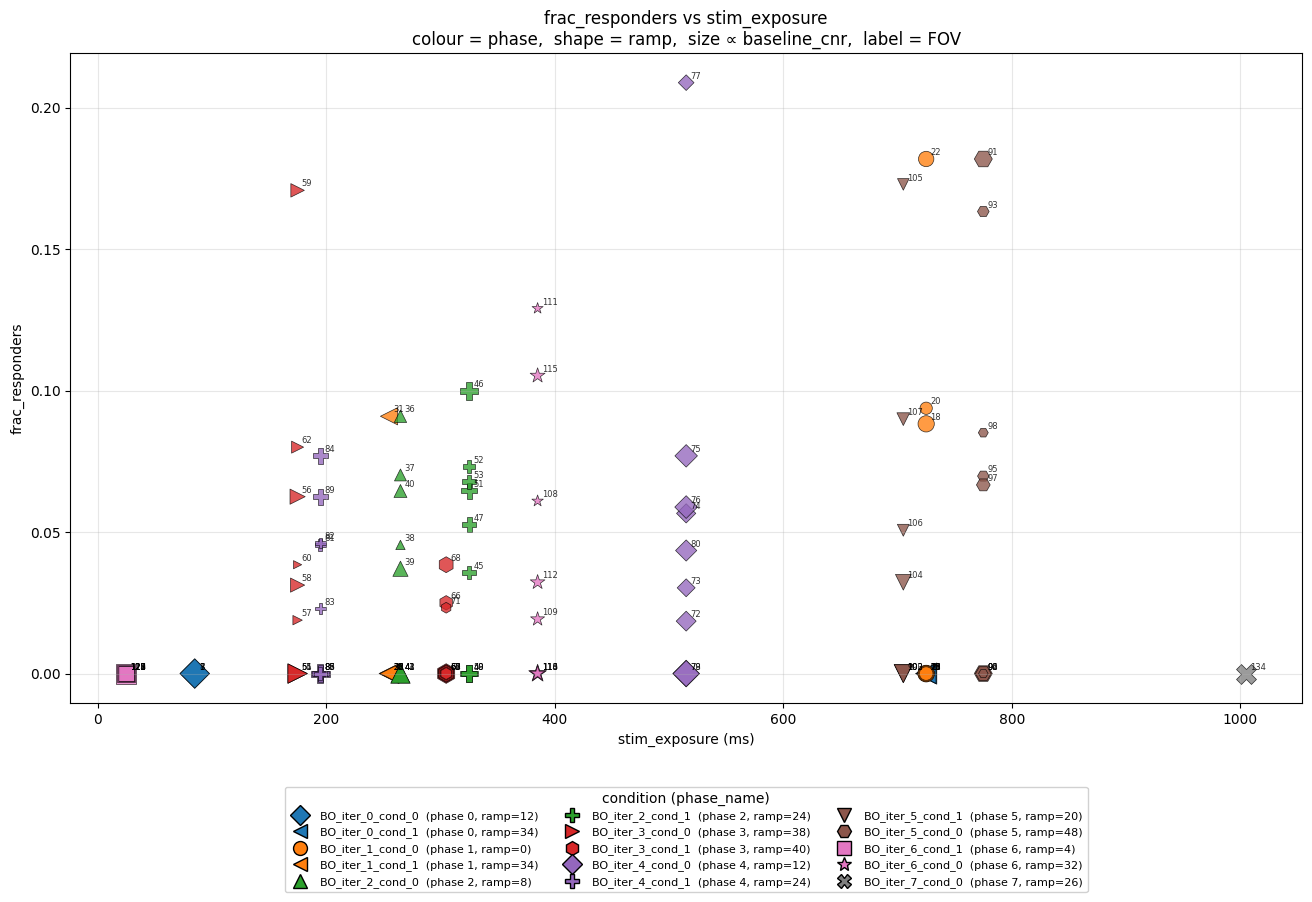

In [24]:
# frac_responders vs stim_exposure
# size ∝ baseline_cnr
from matplotlib.lines import Line2D

pair_to_name = df_fovs_r.groupby(["phase_id", "ramp"])["phase_name"].first().to_dict()

phases_unique = sorted(df_fovs_r["phase_id"].unique())
ramps_unique = sorted(df_fovs_r["ramp"].unique())
cmap = plt.cm.tab10
marker_pool = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H", "p", "8"]
ramp_to_marker = {
    r: marker_pool[i % len(marker_pool)] for i, r in enumerate(ramps_unique)
}

bcn = df_fovs_r["baseline_cnr"].to_numpy(dtype=float)
bcn_min, bcn_max = float(bcn.min()), float(bcn.max())


def size_from_bcn(vals):
    v = np.asarray(vals, dtype=float)
    if bcn_max <= bcn_min:
        return np.full_like(v, 80.0)
    return 35.0 + 200.0 * (v - bcn_min) / (bcn_max - bcn_min)


fig, ax = plt.subplots(figsize=(14, 10))

legend_handles = []
for pid in phases_unique:
    for r in ramps_unique:
        sub = df_fovs_r[(df_fovs_r["phase_id"] == pid) & (df_fovs_r["ramp"] == r)]
        if sub.empty:
            continue
        ax.scatter(
            sub["stim_exposure"],
            sub["frac_responders"],
            c=[cmap(pid % 10)],
            marker=ramp_to_marker[r],
            s=size_from_bcn(sub["baseline_cnr"].to_numpy(dtype=float)),
            alpha=0.78,
            edgecolors="black",
            linewidths=0.5,
        )
        for _, row in sub.iterrows():
            ax.annotate(
                f"{int(row['fov'])}",
                xy=(row["stim_exposure"], row["frac_responders"]),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=6,
                color="black",
                alpha=0.8,
            )
        name = pair_to_name.get((pid, r), f"phase_{pid}_ramp_{r:g}")
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker=ramp_to_marker[r],
                color="w",
                markerfacecolor=cmap(pid % 10),
                markeredgecolor="black",
                markersize=10,
                label=f"{name}  (phase {pid}, ramp={r:g})",
            )
        )

ax.set_xlabel("stim_exposure (ms)")
ax.set_ylabel("frac_responders")
ax.set_title(
    "frac_responders vs stim_exposure\ncolour = phase,  shape = ramp,  size ∝ baseline_cnr,  label = FOV"
)
ax.grid(alpha=0.3)

ax.legend(
    handles=legend_handles,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    title="condition (phase_name)",
    framealpha=0.9,
)
fig.subplots_adjust(left=0.08, right=0.96, top=0.93, bottom=0.28)
plt.show()

## Diagnostic 2 — phase summary

Per-phase mean target + condition parameters.  If the BO is picking
promising regions, later phases should have higher means.  Since v6's
BO actually produced random picks, phases are uncorrelated — but we
can still see if any condition stands out.

 phase_id  n_fovs    stim_values  ramp_values  n_cells_mean  frac_responders_mean  frac_responders_max
        0       8  [85.0, 725.0] [12.0, 34.0]      9.125000              0.000000             0.000000
        1      17 [255.0, 725.0]  [0.0, 34.0]     24.647059              0.026748             0.181818
        2      18 [265.0, 325.0]  [8.0, 24.0]     33.111111              0.038996             0.100000
        3      18 [175.0, 305.0] [38.0, 40.0]     28.222222              0.027140             0.170732
        4      18 [195.0, 515.0] [12.0, 24.0]     38.666667              0.041526             0.208791
        5      17 [705.0, 775.0] [20.0, 48.0]     39.470588              0.053661             0.181818
        6      18  [25.0, 385.0]  [4.0, 32.0]     33.388889              0.019264             0.129032
        7       1       [1005.0]       [26.0]      6.000000              0.000000             0.000000


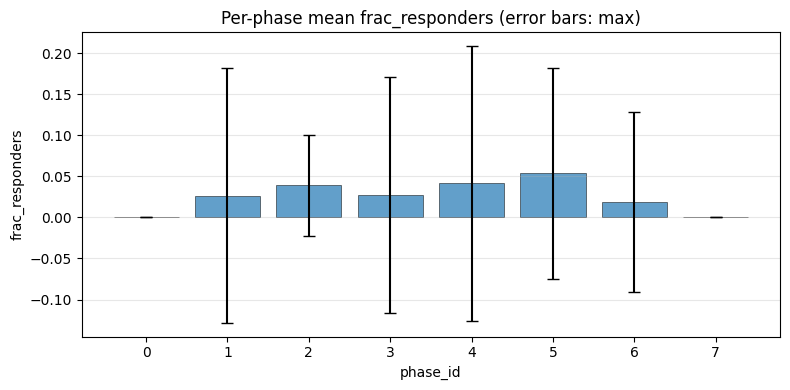


=== Top 10 conditions by mean frac_responders ===
 stim_exposure  ramp  frac_mean  frac_std  n_fovs
         775.0  48.0   0.062958  0.071234       9
         515.0  12.0   0.054827  0.063515       9
         175.0  38.0   0.044646  0.055146       9
         325.0  24.0   0.043759  0.036954       9
         705.0  20.0   0.043202  0.061674       8
         725.0   0.0   0.040423  0.066074       9
         385.0  32.0   0.038529  0.049368       9
         265.0   8.0   0.034232  0.035781       9
         195.0  24.0   0.028224  0.030370       9
         255.0  34.0   0.011364  0.032141       8


In [7]:
phase_summary = (
    df_fovs_r.groupby("phase_id")
    .agg(
        n_fovs=("fov", "count"),
        stim_values=("stim_exposure", lambda s: sorted(s.unique())),
        ramp_values=("ramp", lambda s: sorted(s.unique())),
        n_cells_mean=("n_cells", "mean"),
        frac_responders_mean=("frac_responders", "mean"),
        frac_responders_max=("frac_responders", "max"),
    )
    .reset_index()
)
print(phase_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    phase_summary["phase_id"],
    phase_summary["frac_responders_mean"],
    yerr=phase_summary["frac_responders_max"] - phase_summary["frac_responders_mean"],
    capsize=4,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
)
ax.set_xlabel("phase_id")
ax.set_ylabel("frac_responders")
ax.set_title("Per-phase mean frac_responders (error bars: max)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Top 5 conditions
cond_agg = (
    df_fovs_r.groupby(["stim_exposure", "ramp"])
    .agg(
        frac_mean=("frac_responders", "mean"),
        frac_std=("frac_responders", "std"),
        n_fovs=("frac_responders", "count"),
    )
    .reset_index()
    .sort_values("frac_mean", ascending=False)
)
print("\n=== Top 10 conditions by mean frac_responders ===")
print(cond_agg.head(10).to_string(index=False))

## Diagnostic 3 — fit a GP and look at the landscape

Fit ExactGP+MCMC on `frac_responders` with the FOV covariates
(`baseline_cnr`, `optortk_expression` log-scaled, `n_cells`), then
predict on a dense grid with covariates marginalised (mean over
joint samples from the empirical distribution).

- **If a clear peak emerges**, the BO *would* have benefited from
  guidance (and with the optortk=0 fix in place, it will next run).
- **If the surface is nearly flat**, the parameter range genuinely
  doesn't move oscillation much and the right action is widening
  the range or changing the lever.

In [8]:
bo_covariates_fov = [
    BO_Covariate(name="baseline_cnr"),
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="n_cells"),
]

agent = OscillationBO(
    storage_path=os.path.join(RUN_PATH, "replay_v6_landscape"),
    bo_covariates=bo_covariates_fov,
    objective_metric=BO_Objective(name="frac_responders", goal="maximize"),
    frac_responder_threshold=RESPONDER_THRESHOLD,
    **shared_kwargs,
)
os.makedirs(agent.storage_path, exist_ok=True)
agent.df_results = df_fovs_r.copy()
agent.iteration = len(phases) - 1
agent._last_plot_context = None
params = agent._determine_next_parameters(agent.df_results, verbose=False)
print(f"\nNext GP pick (if we were running BO now): {params}")

sample: 100%|██████████| 1200/1200 [00:05<00:00, 216.50it/s, 7 steps of size 5.94e-01. acc. prob=0.88]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.96      1.76      1.46      0.24      3.79    529.81      1.00
k_length[1]      3.55      3.80      2.42      0.15      6.99    523.46      1.00
k_length[2]      3.16      2.98      2.34      0.19      6.50    724.87      1.01
k_length[3]      2.38      1.95      1.81      0.38      4.51    711.68      1.00
k_length[4]      1.73      1.81      1.19      0.21      3.60    589.69      1.00
    k_scale      0.53      0.28      0.47      0.15      0.90    620.27      1.00
      noise      0.70      0.11      0.69      0.53      0.90    770.29      1.00

Computing robust acquisition over 9020 scenarios (451 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.371025
  Robust acq stats: min=0.013134, max=0.246702

Next GP pick (if we were running BO now): {'stim_exposure': np.float64(1000.0), 'ramp': np.float64(50.0)}


In [9]:
# ARD — what does the GP think matters?
dim_names = [p.name for p in agent.parameters_to_optimize] + [
    c.name for c in agent.bo_covariates
]
ls = np.asarray(agent.model.get_samples()["k_length"])
if ls.ndim > 1:
    ls = ls.mean(axis=0)
ls = ls.squeeze()
rel = 1.0 / ls
rel /= rel.max()
print("ARD lengthscales (small = highly relevant):")
for n, l, r in sorted(zip(dim_names, ls, rel), key=lambda t: t[1]):
    print(f"  {n:28s}  ls={float(l):7.3f}  rel={float(r):.2f}")

ARD lengthscales (small = highly relevant):
  n_cells                       ls=  1.727  rel=1.00
  stim_exposure                 ls=  1.964  rel=0.88
  optortk_expression            ls=  2.382  rel=0.72
  baseline_cnr                  ls=  3.161  rel=0.55
  ramp                          ls=  3.548  rel=0.49


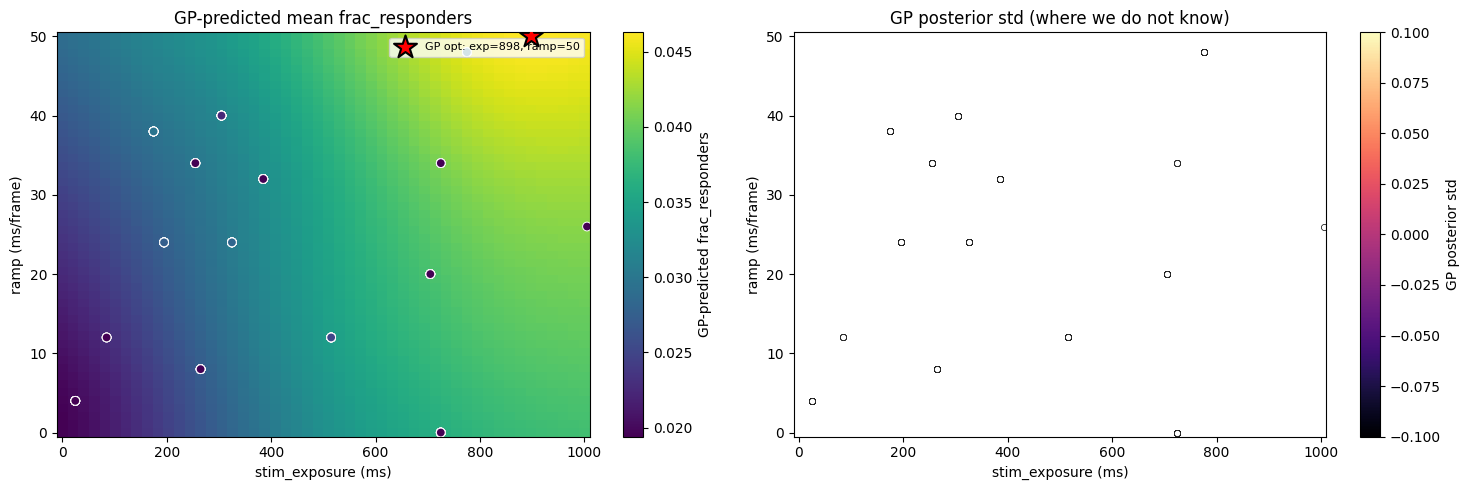


GP peak mean:    0.046
GP valley mean:  0.019
Peak-valley span: 0.027
Mean posterior std across grid: nan
Signal / uncertainty ratio: nan

=> Signal is nanx uncertainty: apparent optimum is credible.
   Peak at (exp=898, ramp=50) with predicted frac_responders=0.046


In [ ]:
# GP-predicted landscape, marginalised over FOV covariates
# Reduced from grid_n=50 / n_mc=50 to grid_n=25 / n_mc=20 because
# gpax ExactGP predict() does per-chunk full covariance over
# ~1200 MCMC samples x 64 posterior draws — scales as
# (grid_n**2 * n_mc * chunk_size) in practice.  25x20 finishes
# in ~1-2 min vs 15+ min at 50x50.
import gpax
import gpax.utils as _gu

rng_key, rng_key_pred = _gu.get_keys()

grid_n = 25
exp_vals = np.linspace(0.0, 1000.0, grid_n)
ramp_vals = np.linspace(0.0, 50.0, grid_n)
E, R = np.meshgrid(exp_vals, ramp_vals, indexing="ij")
ctrl_grid = np.column_stack([E.ravel(), R.ravel()])

rng = np.random.default_rng(0)
n_mc = 20
cov_cols = [c.name for c in bo_covariates_fov]
cov_vals = df_fovs_r[cov_cols].to_numpy(dtype=float)
cov_samples = cov_vals[rng.integers(0, cov_vals.shape[0], size=n_mc)]
x_full = np.hstack(
    [np.repeat(ctrl_grid, n_mc, axis=0), np.tile(cov_samples, (ctrl_grid.shape[0], 1))]
)
print(
    f"Predicting on {x_full.shape[0]} points ({grid_n}x{grid_n} grid x {n_mc} cov samples)..."
)

x_full_scaled = np.asarray(agent._x_scaler.transform(x_full))
chunk = 2000
means, stds = [], []
for i in range(0, x_full_scaled.shape[0], chunk):
    Xb = x_full_scaled[i : i + chunk]
    mean_b, y_samp = agent.model.predict(rng_key_pred, Xb, n=64, noiseless=True)
    mean_b = np.asarray(mean_b).flatten()
    y_samp = np.asarray(y_samp)
    y_flat = y_samp.reshape(-1, y_samp.shape[-1])
    std_b = y_flat.std(axis=0)
    means.append(mean_b)
    stds.append(std_b)
mean_s = np.concatenate(means)
std_s = np.concatenate(stds)

mean_raw = agent._y_scaler.inverse_transform(mean_s.reshape(-1, 1)).flatten()
y_std_scale = float(np.abs(np.asarray(agent._y_scaler.std_)[0]))
std_raw = std_s * y_std_scale

Z_mean = mean_raw.reshape(ctrl_grid.shape[0], n_mc).mean(axis=1).reshape(grid_n, grid_n)
Z_std = std_raw.reshape(ctrl_grid.shape[0], n_mc).mean(axis=1).reshape(grid_n, grid_n)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im = axes[0].pcolormesh(E, R, Z_mean, cmap="viridis", shading="auto")
fig.colorbar(im, ax=axes[0], label="GP-predicted frac_responders")
sc = axes[0].scatter(
    df_fovs_r["stim_exposure"],
    df_fovs_r["ramp"],
    c=df_fovs_r["frac_responders"],
    cmap="viridis",
    s=40,
    edgecolors="white",
    linewidths=0.7,
)
opt_i = int(np.argmax(Z_mean))
axes[0].scatter(
    E.ravel()[opt_i],
    R.ravel()[opt_i],
    c="red",
    s=300,
    marker="*",
    edgecolors="black",
    linewidths=1.5,
    zorder=10,
    label=f"GP opt: exp={E.ravel()[opt_i]:.0f}, ramp={R.ravel()[opt_i]:.0f}",
)
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_xlabel("stim_exposure (ms)")
axes[0].set_ylabel("ramp (ms/frame)")
axes[0].set_title("GP-predicted mean frac_responders")

im = axes[1].pcolormesh(E, R, Z_std, cmap="magma", shading="auto")
fig.colorbar(im, ax=axes[1], label="GP posterior std")
axes[1].scatter(
    df_fovs_r["stim_exposure"],
    df_fovs_r["ramp"],
    c="white",
    s=20,
    edgecolors="black",
    linewidths=0.5,
)
axes[1].set_xlabel("stim_exposure (ms)")
axes[1].set_ylabel("ramp (ms/frame)")
axes[1].set_title("GP posterior std (where we do not know)")

plt.tight_layout()
plt.show()

peak_mean = float(Z_mean.max())
valley_mean = float(Z_mean.min())
mean_std = float(Z_std.mean())
signal_span = peak_mean - valley_mean
print(f"GP peak mean:    {peak_mean:.3f}")
print(f"GP valley mean:  {valley_mean:.3f}")
print(f"Peak-valley span: {signal_span:.3f}")
print(f"Mean posterior std across grid: {mean_std:.3f}")
print(f"Signal / uncertainty ratio: {signal_span / max(mean_std, 1e-9):.2f}")
if signal_span < 2.0 * mean_std:
    print("=> Signal is <= 2*uncertainty: SURFACE IS EFFECTIVELY FLAT.")
    print("   No credible optimum in the tested range; widen parameters.")
else:
    print(
        f"=> Signal is {signal_span/mean_std:.1f}x uncertainty: apparent optimum is credible."
    )
    print(
        f"   Peak at (exp={E.ravel()[opt_i]:.0f}, ramp={R.ravel()[opt_i]:.0f}) "
        f"with predicted frac_responders={peak_mean:.3f}"
    )

## Diagnostic 4 — honest holdout

Hold out the last phase, refit on the rest, check if the GP predicts
the held-out phase better than predicting the mean.  This is the
strictest test of "does (exposure, ramp) carry signal?" — if
holdout R² > 0, the tested range moves the outcome meaningfully.

In [ ]:
# Pick a holdout phase that actually has data (max(phases) may be
# partially empty if the prior run was interrupted and its FOVs were
# dropped upstream).
phase_counts = df_fovs_r.groupby("phase_id").size()
# Prefer the largest phase_id that still has >= 3 FOVs.
valid_phases = sorted([int(p) for p, n in phase_counts.items() if n >= 3])
if not valid_phases:
    raise RuntimeError("No phase has >=3 FOVs; cannot do holdout.")
HOLDOUT_PHASE = valid_phases[-1]

df_tr = df_fovs_r[df_fovs_r["phase_id"] != HOLDOUT_PHASE]
df_te = df_fovs_r[df_fovs_r["phase_id"] == HOLDOUT_PHASE]
print(f"Holdout phase {HOLDOUT_PHASE}: train n={len(df_tr)}, test n={len(df_te)}")
if len(df_te) == 0:
    raise RuntimeError(f"Holdout phase {HOLDOUT_PHASE} has no FOVs; check data.")

agent.df_results = df_tr.copy()
agent._last_plot_context = None
_ = agent._determine_next_parameters(df_tr, verbose=False)

cols = [p.name for p in agent.parameters_to_optimize] + [
    c.name for c in agent.bo_covariates
]
X_te = df_te[cols].to_numpy(dtype=float)
y_te = df_te["frac_responders"].to_numpy(dtype=float)

X_te_scaled = np.asarray(agent._x_scaler.transform(X_te))
chunk = 2000
m_list, s_list = [], []
rng_key, rng_key_p = _gu.get_keys()
for i in range(0, X_te_scaled.shape[0], chunk):
    Xb = X_te_scaled[i : i + chunk]
    mean_b, y_samp = agent.model.predict(rng_key_p, Xb, n=64, noiseless=True)
    y_samp = np.asarray(y_samp)
    m_list.append(np.asarray(mean_b).flatten())
    s_list.append(y_samp.reshape(-1, y_samp.shape[-1]).std(axis=0))

if not m_list:
    raise RuntimeError("No predictions produced; holdout set was empty after all.")

m_scaled = np.concatenate(m_list)
s_scaled = np.concatenate(s_list)
m_pred = agent._y_scaler.inverse_transform(m_scaled.reshape(-1, 1)).flatten()
y_std_scale = float(np.abs(np.asarray(agent._y_scaler.std_)[0]))
s_pred = s_scaled * y_std_scale

resid = y_te - m_pred
r2 = 1.0 - float(np.sum(resid**2)) / max(
    float(np.sum((y_te - y_te.mean()) ** 2)), 1e-12
)
rmse = float(np.sqrt(np.mean(resid**2)))
cov = float(
    np.mean((y_te >= m_pred - 1.96 * s_pred) & (y_te <= m_pred + 1.96 * s_pred))
)
z_std = float(np.std(resid / np.maximum(s_pred, 1e-12)))
print(f"Holdout R2       = {r2:+.3f}")
print(
    f"Holdout RMSE     = {rmse:.4f}   (target std on train = {df_tr['frac_responders'].std():.4f})"
)
print(f"Holdout coverage = {cov:.3f}   (target ~0.95)")
print(f"Holdout z-std    = {z_std:.3f}   (target ~1.0)")

fig, ax = plt.subplots(figsize=(6, 5))
ax.errorbar(y_te, m_pred, yerr=1.96 * s_pred, fmt="o", alpha=0.6, ms=5, lw=0.8)
lo = min(y_te.min(), m_pred.min())
hi = max(y_te.max(), m_pred.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlabel("observed (holdout)")
ax.set_ylabel("GP predicted (+/- 1.96 sigma)")
ax.set_title(f"Holdout phase {HOLDOUT_PHASE}: R2={r2:+.3f}")
plt.tight_layout()
plt.show()

Holdout phase 8: train n=115, test n=0


sample: 100%|██████████| 1200/1200 [00:05<00:00, 222.50it/s, 7 steps of size 5.94e-01. acc. prob=0.88]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.96      1.76      1.46      0.24      3.79    529.81      1.00
k_length[1]      3.55      3.80      2.42      0.15      6.99    523.46      1.00
k_length[2]      3.16      2.98      2.34      0.19      6.50    724.87      1.01
k_length[3]      2.38      1.95      1.81      0.38      4.51    711.68      1.00
k_length[4]      1.73      1.81      1.19      0.21      3.60    589.69      1.00
    k_scale      0.53      0.28      0.47      0.15      0.90    620.27      1.00
      noise      0.70      0.11      0.69      0.53      0.90    770.29      1.00

Computing robust acquisition over 9000 scenarios (450 grid points x 20 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.399175
  Robust acq stats: min=0.003077, max=0.172842


ValueError: need at least one array to concatenate

## Final verdict

Combine the four diagnostics:

- **Scatter plots**: visual trend or no visual trend?
- **Phase summary**: any condition standout, or all phases similar?
- **Landscape span vs uncertainty**: signal/uncertainty ratio > 2?
- **Holdout R²**: positive means the GP extrapolates; zero/negative
  means noise dominates.

If signal/uncertainty > 2 **and** holdout R² > 0 **and** scatter
shows a visible trend → there's a real optimum worth pursuing in
the next BO run.  Otherwise the current parameter range probably
doesn't move the outcome strongly and the action is to widen
bounds or change the lever.